<p style="color:blue;">UNIVERSIDAD DE SAN CARLOS DE GUATEMALA</p>
<p style="color:blue;">FACULTAD DE INGENIERÍA</p>
<p style="color:blue;">INGENIERÍA EN CIENCIAS Y SISTEMAS</p>
<p style="color:blue;">SEMINARIO DE SISTEMAS 2</p>
<p style="color:blue;">SECCIÓN A</p>
<p style="color:blue;">INGRID LORENA GARCIA YANTUCHE</p>
<p style="color:blue;">CARNÉ: 201700399</p>
<p style="color:blue;">PRÁCTICA 2</p>

Instalación de las librerias necesarias a utilizar en el entorno de trabajo, se ejecuto el siguiente comando:
-  pip install pandas numpy matplotlib seaborn nltk

Posteriormente se realizo la importación de las librerías a utilizar.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re

# Carga de datos  .csv

Se realizó la carga del archivo "datos.csv" de Coursera usando la librería Pandas
- > read_csv('datos.csv')

In [71]:
df = pd.read_csv('datos.csv')
total_filas = len(df)
print(f'El archivo CSV contiene {total_filas} filas.')

El archivo CSV contiene 9595 filas.


# Limpieza de datos

De los datos cargados se procedió a realizar una limpieza de datos como primer paso se realizó la eliminación de valores nulos o vacios.
- > isnull().sum()
- > dropna(inplace=True)

In [72]:
df.isnull().sum()
df.dropna(inplace=True)
print('Filas: ' ,len(df))

Filas:  3517


Eliminación de datos duplicados
- > drop_duplicates()
- > fillna(0)

In [73]:
df = df.drop_duplicates()
df = df.fillna(0)
print('Filas: ' ,len(df))

Filas:  3227


Convertir la columna 'Duration' a horas: de los datos cargados se observó que la columna 'Duration' tenia este formato
- Approx. 44 hours to complete
- 2 months at 10 hours a week

Para la realización de un mejor análisis se decidió trabajar en horas 

In [76]:
def durationHoras(duration):
    duration = str(duration)
    
    if "hours" and "week" not in duration:
        hours = re.findall(r'\d+', duration)  
        if hours:
            return int(hours[0]) 
        else:
            return 0
        
    # 2 months at 10 hours a week           
    elif "months" in duration and "week" in duration:
        months_and_hours = re.findall(r'\d+', duration)
        print(months_and_hours)
        if len(months_and_hours) == 2:
            months = int(months_and_hours[0])  
            hours_per_week = int(months_and_hours[1])  
            total_weeks = months * 4 
            return total_weeks * hours_per_week 
        else:
            return 0 
    
    return 0

df['Duration'] = df['Duration'].apply(durationHoras)

df.to_csv('datos2.csv', index=False)
df[['Duration']].head()

,Duration
4,11
5,5
13,10
21,21
28,52


# Cálculo del promedio de calificaciones para cada curso

C:\Users\logas\AppData\Local\Temp\ipykernel_19276\3953957908.py:26: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\3953957908.py:26: UserWarning: Glyph 30990 (\N{CJK UNIFIED IDEOGRAPH-790E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\3953957908.py:26: UserWarning: Glyph 30693 (\N{CJK UNIFIED IDEOGRAPH-77E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\3953957908.py:26: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\3953957908.py:26: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\3953957908.py:26: UserWarning: Glyph 12487 (\N{KATAKANA 

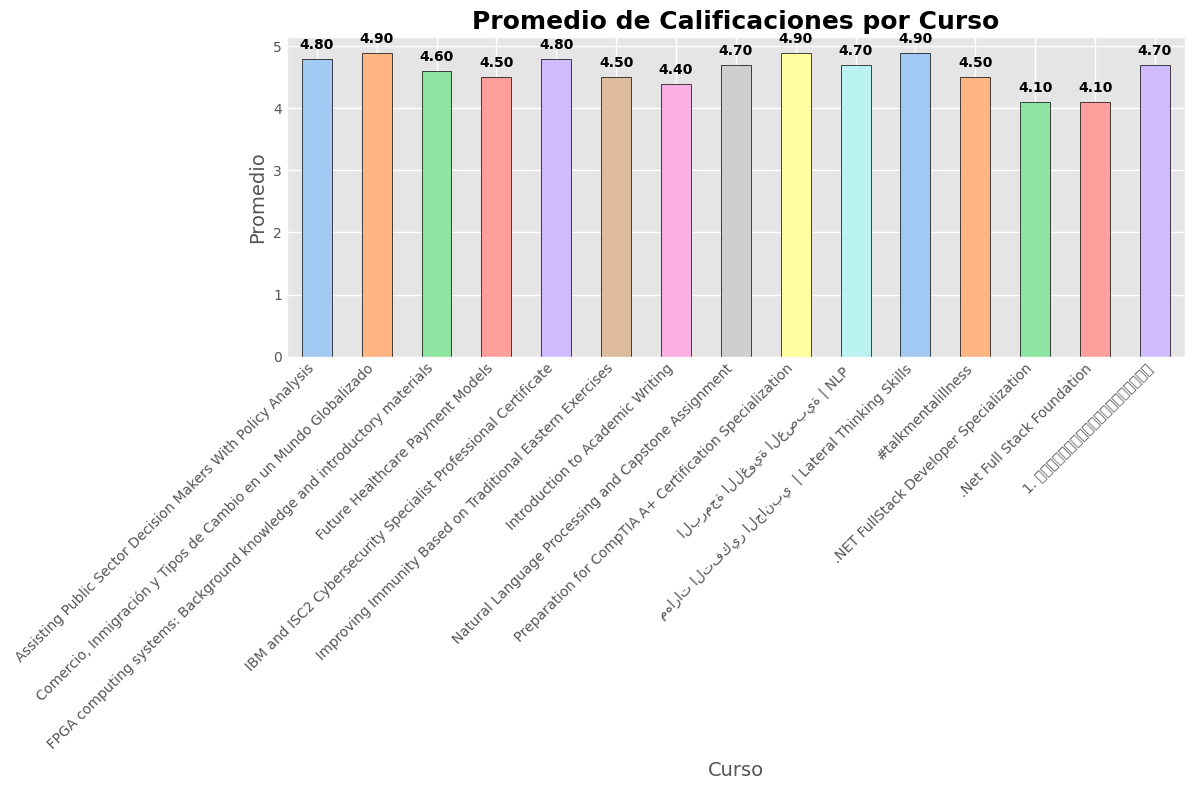

In [92]:
plt.style.use('ggplot')

df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
promedio = df.groupby('Course Title')['Rating'].mean()

colors = sns.color_palette("pastel", 15)

plt.figure(figsize=(12, 8))

bars = promedio.head(15).plot(kind='bar', color=colors, edgecolor='black')
# Etiquetas de gráfica
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():.2f}', 
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='center', 
                  xytext=(0, 10), 
                  textcoords='offset points', 
                  fontsize=10, fontweight='bold')

plt.title('Promedio de Calificaciones por Curso', fontsize=18, fontweight='bold')
plt.ylabel('Promedio', fontsize=14)
plt.xlabel('Curso', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()